In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [4]:
cols = ["engine_id","cycle"] + \
       [f"setting{i}" for i in range(1,4)] + \
       [f"sensor{i}" for i in range(1,22)]

train = pd.read_csv("E:/Mrinalika/Zaalima Internship/dataset/train_FD001.txt", sep="\s+", header=None)
train.columns = cols

train.head()

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16968\3773790128.py:5: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv("E:/Mrinalika/Zaalima Internship/dataset/train_FD001.txt", sep="\s+", header=None)


,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
print("Shape:", train.shape)
train.info()
train.describe()

Shape: (20631, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting1   20631 non-null  float64
 3   setting2   20631 non-null  float64
 4   setting3   20631 non-null  float64
 5   sensor1    20631 non-null  float64
 6   sensor2    20631 non-null  float64
 7   sensor3    20631 non-null  float64
 8   sensor4    20631 non-null  float64
 9   sensor5    20631 non-null  float64
 10  sensor6    20631 non-null  float64
 11  sensor7    20631 non-null  float64
 12  sensor8    20631 non-null  float64
 13  sensor9    20631 non-null  float64
 14  sensor10   20631 non-null  float64
 15  sensor11   20631 non-null  float64
 16  sensor12   20631 non-null  float64
 17  sensor13   20631 non-null  float64
 18  sensor14   20631 non-null  float64
 19  sensor15   20631 non-null  

,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [6]:
#Create RUL (Target Foundation)
max_cycles = train.groupby("engine_id")["cycle"].transform("max")
train["RUL"] = max_cycles - train["cycle"]

train[["engine_id","cycle","RUL"]].head()

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [7]:
#Convert into classification problem
train["failure_soon"] = (train["RUL"] <= 30).astype(int)

train["failure_soon"].value_counts()

failure_soon
0    17531
1     3100
Name: count, dtype: int64

In [8]:
#Remove constant columns
constant_cols = train.columns[train.nunique() <= 1]
print("Constant columns:", list(constant_cols))

train = train.drop(columns=constant_cols)

Constant columns: ['setting3', 'sensor1', 'sensor5', 'sensor10', 'sensor16', 'sensor18', 'sensor19']


In [9]:
#Feture engineering
window_sizes = [5, 10]

for w in window_sizes:
    train[f"sensor2_rollmean_{w}"] = train.groupby("engine_id")["sensor2"].transform(lambda x: x.rolling(w).mean())
    train[f"sensor4_rollstd_{w}"] = train.groupby("engine_id")["sensor4"].transform(lambda x: x.rolling(w).std())

# Lag features
train["sensor2_lag1"] = train.groupby("engine_id")["sensor2"].shift(1)
train["sensor2_lag2"] = train.groupby("engine_id")["sensor2"].shift(2)

train = train.dropna()

print("After feature engineering:", train.shape)

After feature engineering: (19731, 27)


In [14]:
X = train.drop(columns=["engine_id","cycle","RUL","failure_soon"])
y = train["failure_soon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [15]:
#random forest
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict_proba(X_test)[:,1]
rf_score = average_precision_score(y_test, rf_pred)

print("Random Forest PR-AUC:", rf_score)

Random Forest PR-AUC: 0.941938321759891


In [17]:
#XGBoost
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict_proba(X_test)[:,1]
xgb_score = average_precision_score(y_test, xgb_pred)

print("XGBoost PR-AUC:", xgb_score)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:48:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost PR-AUC: 0.9504823194536172


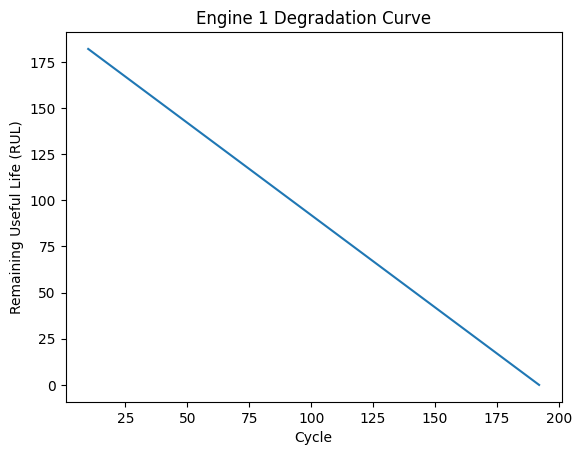

In [ ]:
#RUL Degradation Curve
import matplotlib.pyplot as plt
engine_id = 1
engine_data = train[train["engine_id"] == engine_id]

plt.figure()
plt.plot(engine_data["cycle"], engine_data["RUL"])
plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life (RUL)")
plt.title("Engine 1 Degradation Curve")
plt.show()

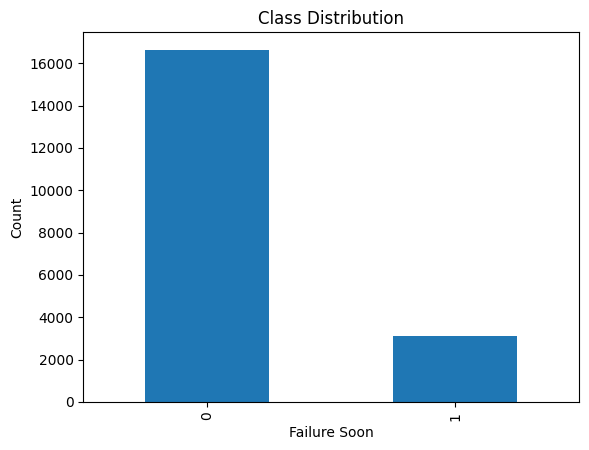

In [ ]:
#Class Imbalance Plot
train["failure_soon"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Failure Soon")
plt.ylabel("Count")
plt.show()

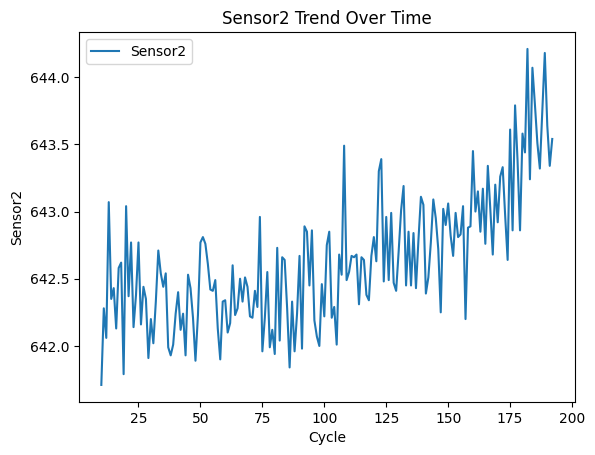

In [ ]:
#Sensor Trend Before Failure
plt.figure()

plt.plot(engine_data["cycle"], engine_data["sensor2"], label="Sensor2")
plt.xlabel("Cycle")
plt.ylabel("Sensor2")
plt.title("Sensor2 Trend Over Time")
plt.legend()
plt.show()

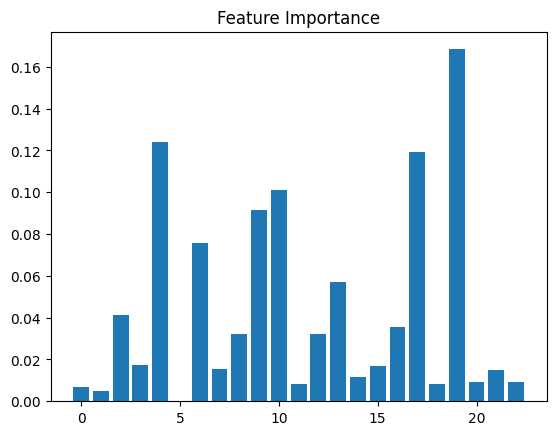

In [24]:
#feature importance
importances = rf_model.feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()